# IIVP - EDA

## Load Libs

In [1]:
from __future__ import annotations

import os, cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import glob, random, hashlib, warnings
from collections import Counter

import pandas as pd
import matplotlib as mpl
import seaborn as sns
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import module1_preprocessing as m1

warnings.filterwarnings("ignore")

## Initialize

In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
rng = np.random.default_rng(SEED)

sns.set_theme(context="notebook", style="whitegrid", palette="viridis")
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 140,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.family": "DejaVu Sans",
})

DATA_DIR  = "data"
TRAIN_DIR = os.path.join(DATA_DIR, "train", "train")
TEST_DIR  = os.path.join(DATA_DIR, "test", "test")
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV  = os.path.join(DATA_DIR, "test.csv")
NUM_CLASSES = 10
CLASS_PALETTE = sns.color_palette("tab10", n_colors=NUM_CLASSES)

train_csv = pd.read_csv(TRAIN_CSV)
test_csv  = pd.read_csv(TEST_CSV)

train_disk = {}  # id -> (label, path)
for cls in range(NUM_CLASSES):
    for p in glob.glob(os.path.join(TRAIN_DIR, str(cls), "*.png")):
        fid = int(os.path.splitext(os.path.basename(p))[0])
        train_disk[fid] = (cls, p)

test_disk = {}
for p in glob.glob(os.path.join(TEST_DIR, "*.png")):
    fid = int(os.path.splitext(os.path.basename(p))[0])
    test_disk[fid] = p
    
print("OpenCV :", cv2.__version__)
print("NumPy  :", np.__version__)
print("Pandas :", pd.__version__)

OpenCV : 4.13.0
NumPy  : 2.3.3
Pandas : 2.3.2


## Module 1

In [3]:
sample_img_path = os.path.join(TRAIN_DIR, "0", "4558.png")
raw_img = cv2.imread(sample_img_path)

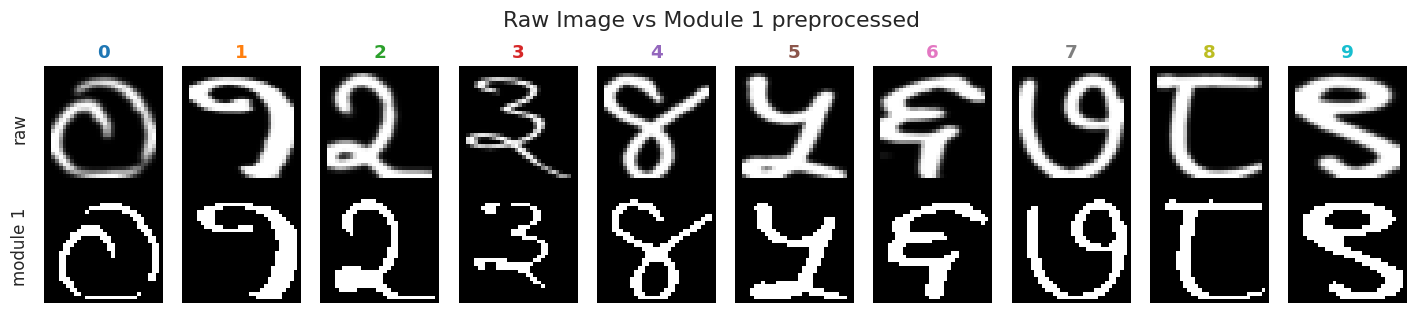

In [4]:
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES * 1.3, 3.0))
for cls in range(NUM_CLASSES):
    p = next(p for fid,(lbl,p) in train_disk.items() if lbl == cls)
    raw = cv2.imread(p)
    proc = m1.preprocess_image(raw)
    axes[0, cls].imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB))
    axes[0, cls].set_title(str(cls), color=CLASS_PALETTE[cls], fontweight="bold")
    axes[0, cls].axis("off")
    axes[1, cls].imshow(proc, cmap="gray")
    axes[1, cls].axis("off")
axes[0, 0].text(-7, raw.shape[0] / 2, "raw",       rotation=90,
                va="center", ha="center", fontsize=11)
axes[1, 0].text(-7,  m1.IMG_SIZE / 2,    "module 1", rotation=90,
                va="center", ha="center", fontsize=11)
plt.suptitle("Raw Image vs Module 1 preprocessed", y=0.95)
plt.tight_layout(); plt.show()

## Load grayscale images into the memory

In [5]:
IMG_SIZE = 32

def load_gray(path, size=None):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    if size:
        img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    return img

def load_all_gray_train():
    X, y, ids = [], [], []
    for fid, (lbl, p) in train_disk.items():
        img = load_gray(p, size=(IMG_SIZE, IMG_SIZE))
        if img is None: continue
        X.append(img); y.append(lbl); ids.append(fid)
    return np.asarray(X, np.uint8), np.asarray(y), np.asarray(ids)

def load_all_gray_test():
    X, ids = [], []
    for fid, p in test_disk.items():
        img = load_gray(p, size=(IMG_SIZE, IMG_SIZE))
        if img is None: continue
        X.append(img); ids.append(fid)
    return np.asarray(X, np.uint8), np.asarray(ids)

X_tr, y_tr, ids_tr = load_all_gray_train()
X_te, ids_te       = load_all_gray_test()
print("X_tr:", X_tr.shape, X_tr.dtype, " | X_te:", X_te.shape, X_te.dtype)


X_tr: (17000, 32, 32) uint8  | X_te: (3000, 32, 32) uint8


## Image quality metrics

In [6]:
def image_quality(img):
    bright = float(img.mean())
    contrast = float(img.std())
    sharp = float(cv2.Laplacian(img, cv2.CV_64F).var())
    edges = cv2.Canny(img, 80, 160)
    edge_density = float((edges > 0).mean())
    _, bw = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    fg_ratio = float((bw > 0).mean())
    return bright, contrast, sharp, edge_density, fg_ratio

cols = ["brightness", "contrast", "sharpness", "edge_density", "fg_ratio"]
qm = np.array([image_quality(im) for im in X_tr])
qual_df = pd.DataFrame(qm, columns=cols)
qual_df["class"] = y_tr
qual_df.describe().round(3)


,brightness,contrast,sharpness,edge_density,fg_ratio,class
count,17000.000,17000.000,17000.000,17000.000,17000.000,17000.000
mean,61.791,96.568,10483.188,0.159,0.248,4.500
std,18.567,12.373,3101.477,0.020,0.069,2.872
min,13.968,42.737,2440.510,0.087,0.071,0.000
25%,49.387,90.634,8205.975,0.146,0.201,2.000
50%,60.392,98.555,10097.884,0.158,0.242,4.500
75%,73.655,105.479,12347.514,0.173,0.291,7.000
max,145.309,119.723,27247.539,0.236,0.572,9.000


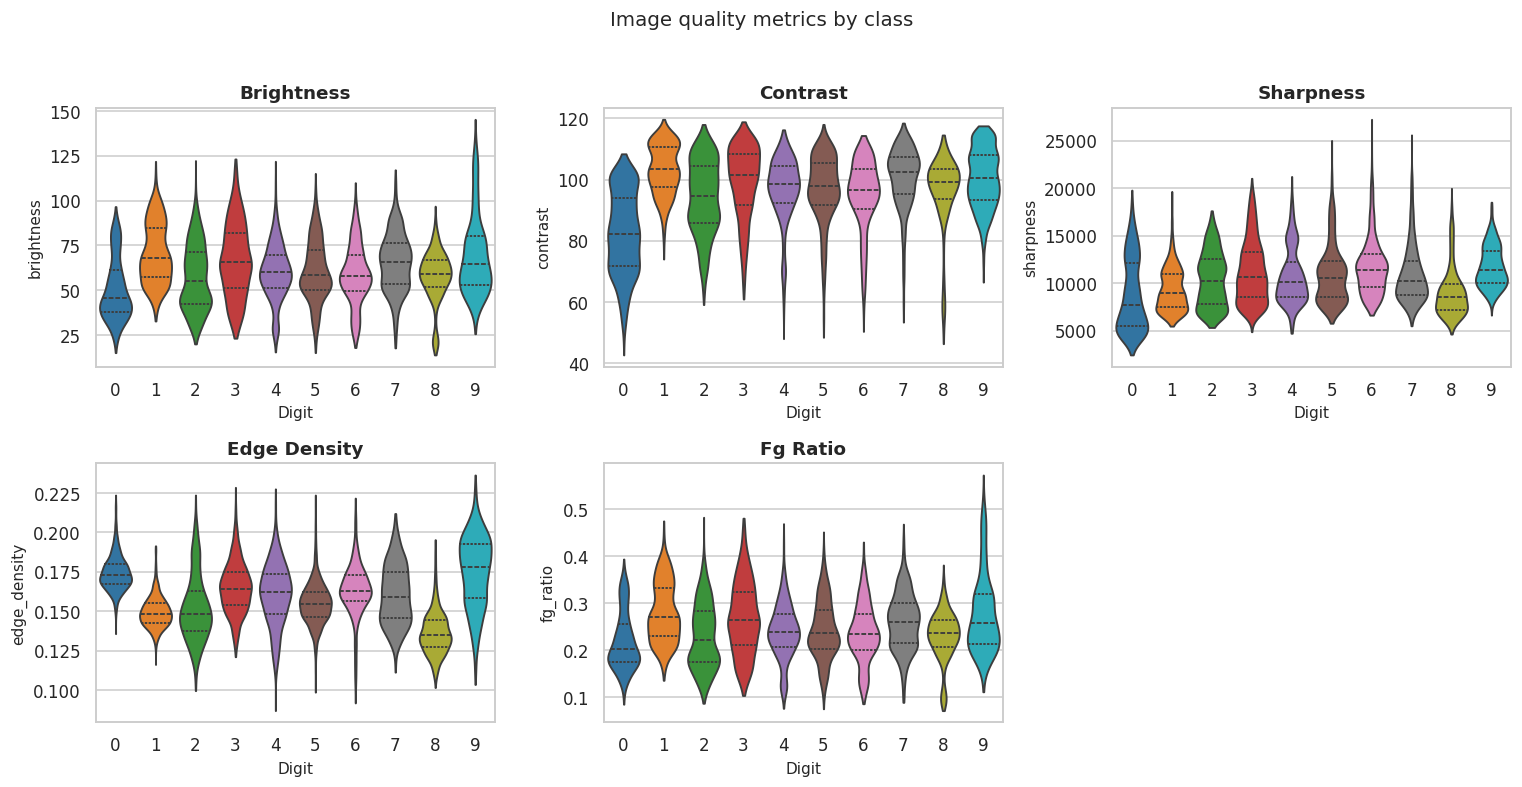

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.flat, cols):
    sns.violinplot(data=qual_df, x="class", y=c, palette=CLASS_PALETTE,
                   ax=ax, inner="quartile", cut=0)
    ax.set_title(c.replace("_", " ").title())
    ax.set_xlabel("Digit")
axes[1, 2].axis("off")
plt.suptitle("Image quality metrics by class", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()


In [8]:
# Aggregate statistics
sample_idx = rng.choice(len(ids_tr), size=1000, replace=False)
sample_paths = [train_disk[int(ids_tr[i])][1] for i in sample_idx]

raw_stats, proc_stats = [], []
for p in sample_paths:
    raw = cv2.imread(p)
    if raw is None: continue
    g = cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY)
    g = cv2.resize(g, (m1.IMG_SIZE, m1.IMG_SIZE), interpolation=cv2.INTER_AREA)
    raw_stats.append(image_quality(g))
    proc = (m1.preprocess_image(raw) * 255).astype(np.uint8)
    proc_stats.append(image_quality(proc))

raw_arr  = np.array(raw_stats)
proc_arr = np.array(proc_stats)

cmp_df = pd.DataFrame({
    "metric": cols,
    "raw_mean":   raw_arr.mean(axis=0).round(3),
    "proc_mean":  proc_arr.mean(axis=0).round(3),
    "raw_std":    raw_arr.std(axis=0).round(3),
    "proc_std":   proc_arr.std(axis=0).round(3),
})
display(cmp_df)


,metric,raw_mean,proc_mean,raw_std,proc_std
0,brightness,62.025,47.657,18.305,15.003
1,contrast,96.821,97.576,11.938,11.629
2,sharpness,10449.807,37718.670,3127.738,6093.298
3,edge_density,0.159,0.119,0.020,0.017
4,fg_ratio,0.249,0.187,0.068,0.059


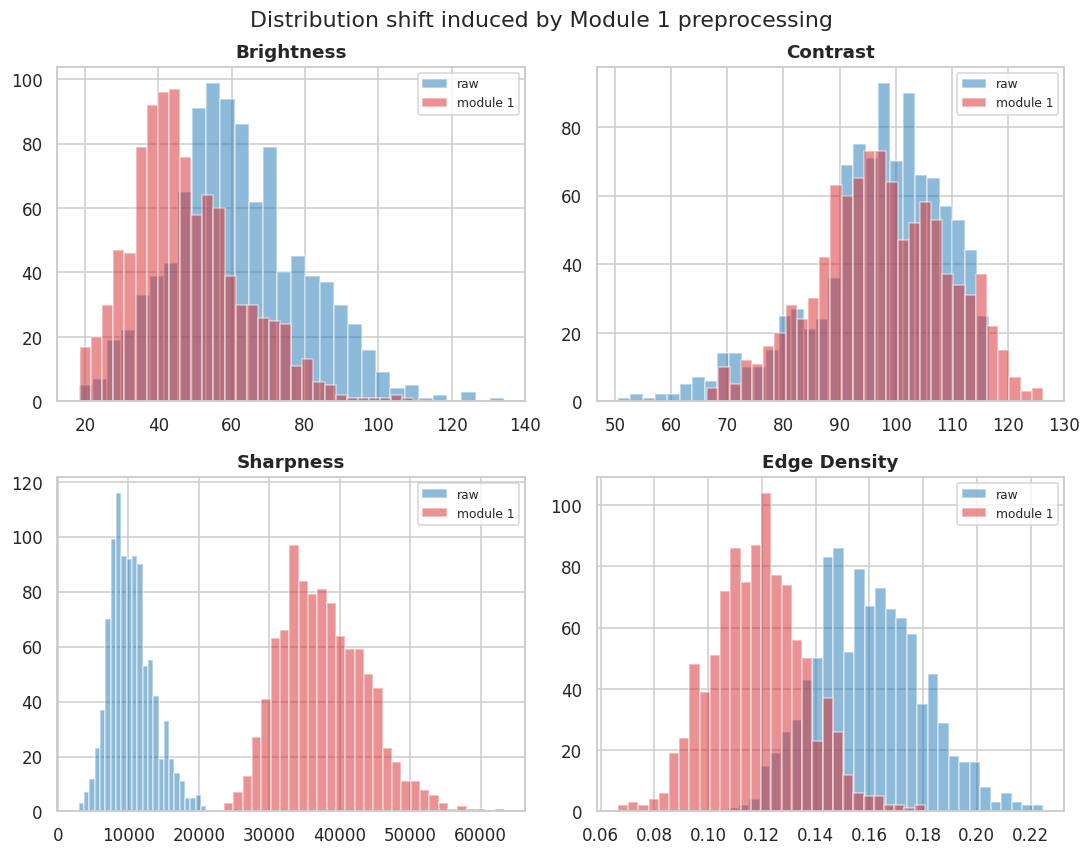

In [9]:
fig, axes = plt.subplots(2, len(cols) // 2, figsize=(10, 8))
axes = axes.flatten()
for ax, c, i in zip(axes, cols, range(len(cols))):
    ax.hist(raw_arr[:, i],  bins=30, alpha=0.5, label="raw",
            color=CLASS_PALETTE[0])
    ax.hist(proc_arr[:, i], bins=30, alpha=0.5, label="module 1",
            color=CLASS_PALETTE[3])
    ax.set_title(c.replace("_", " ").title())
    ax.legend(fontsize=8)
plt.suptitle("Distribution shift induced by Module 1 preprocessing", y=0.97)
plt.tight_layout(); plt.show()


## Outliers

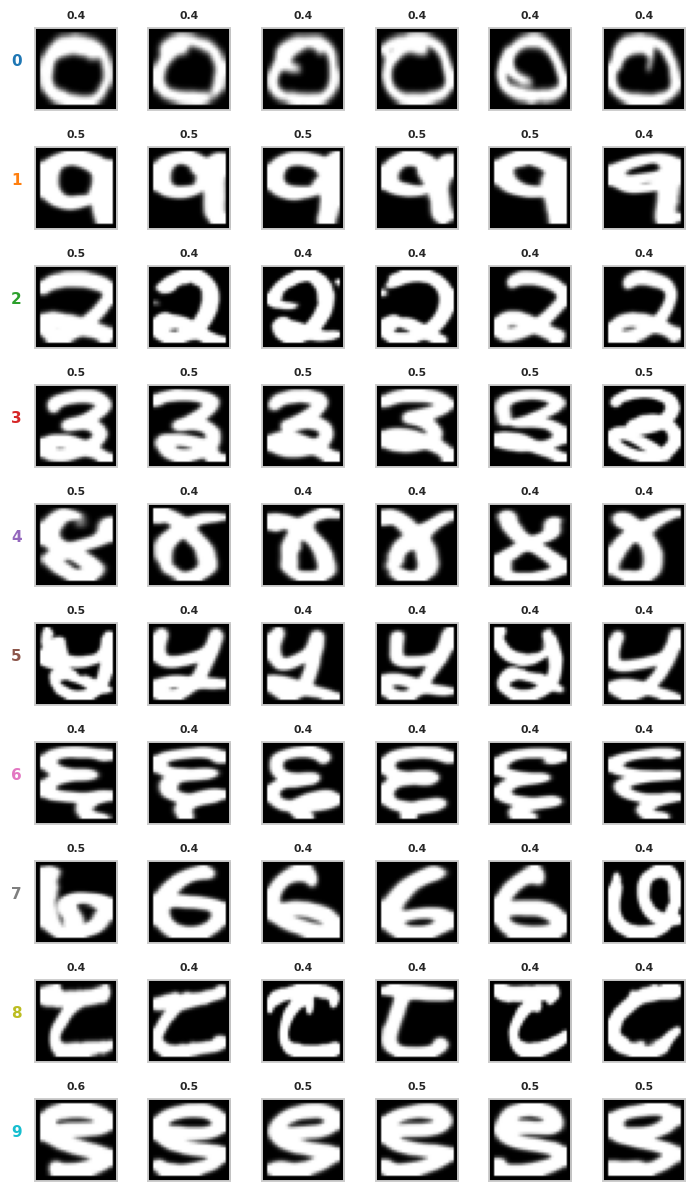

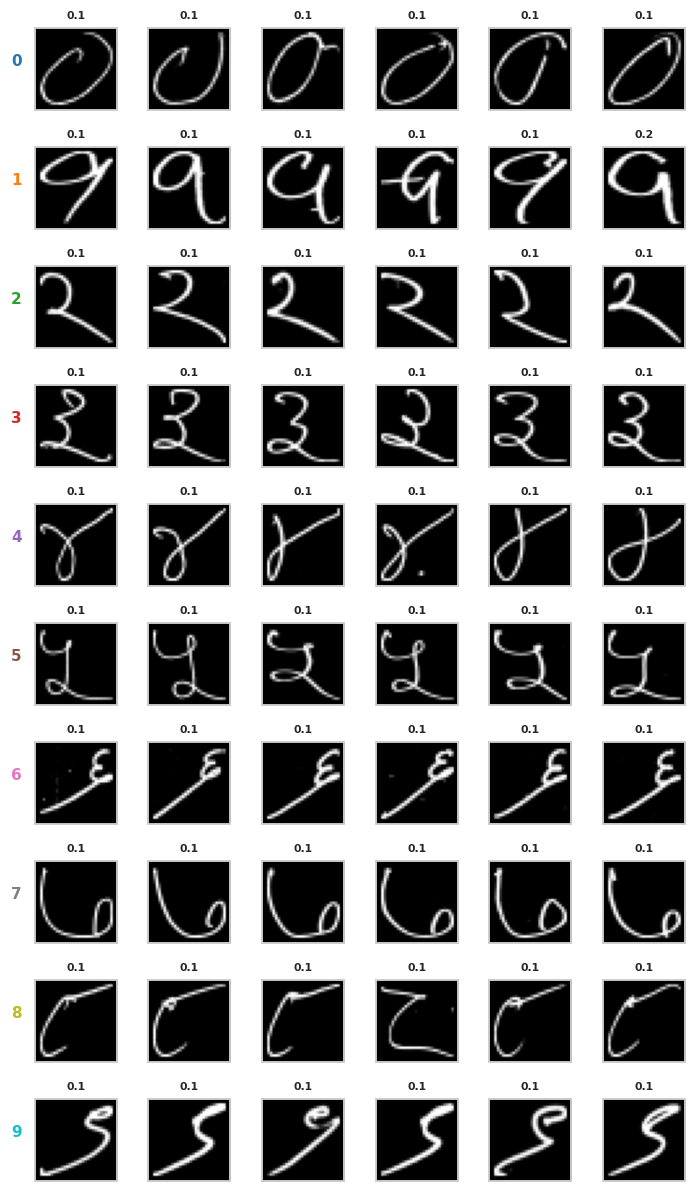

In [10]:
def show_outliers(metric_name, ascending=True, k=8):
    title = f"Lowest {metric_name}" if ascending else f"Highest {metric_name}"
    fig, axes = plt.subplots(NUM_CLASSES, k,
                             figsize=(k * 1.1, NUM_CLASSES * 1.1))
    for cls in range(NUM_CLASSES):
        sub = qual_df[qual_df["class"] == cls].copy()
        sub = sub.sort_values(metric_name, ascending=ascending).head(k)
        for j, (_, row) in enumerate(sub.iterrows()):
            ax = axes[cls, j]
            ax.imshow(X_tr[row.name], cmap="gray")
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_title(f"{row[metric_name]:.1f}", fontsize=7)
            if j == 0:
                ax.set_ylabel(str(cls), rotation=0, labelpad=12,
                              color=CLASS_PALETTE[cls], fontweight="bold")
    plt.tight_layout(); plt.show()

#show_outliers("sharpness", ascending=True, k=6)
show_outliers("fg_ratio",  ascending=False, k=6)
show_outliers("fg_ratio",  ascending=True,  k=6)


## Class means

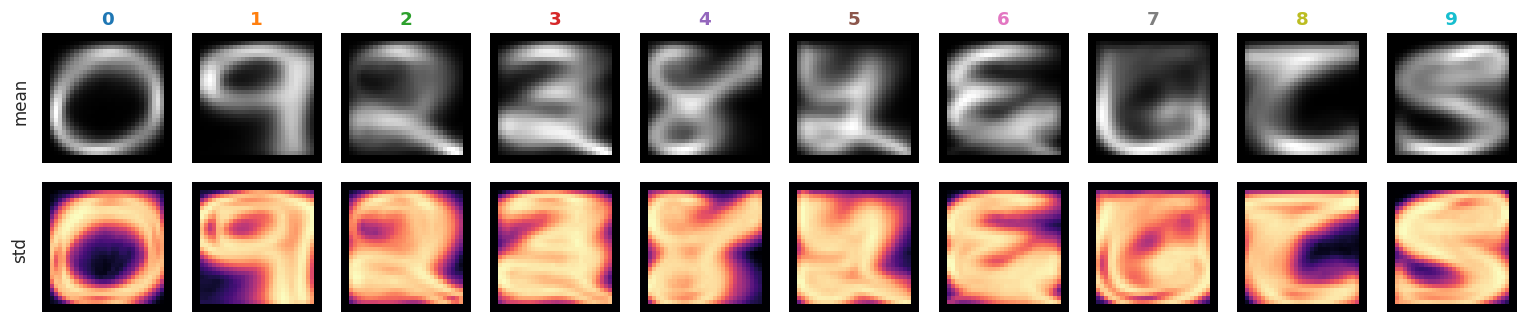

In [11]:
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES * 1.4, 3.2))
for cls in range(NUM_CLASSES):
    Xc = X_tr[y_tr == cls].astype(np.float32)
    mean_img = Xc.mean(axis=0)
    std_img  = Xc.std(axis=0)

    axes[0, cls].imshow(mean_img, cmap="gray")
    axes[0, cls].set_title(str(cls), color=CLASS_PALETTE[cls], fontweight="bold")
    axes[0, cls].axis("off")

    axes[1, cls].imshow(std_img, cmap="magma")
    axes[1, cls].axis("off")

axes[0, 0].text(-6, IMG_SIZE / 2, "mean", rotation=90,
                va="center", ha="center", fontsize=11)
axes[1, 0].text(-6, IMG_SIZE / 2, "std",  rotation=90,
                va="center", ha="center", fontsize=11)
plt.tight_layout();
plt.show()


## Inter class similarity

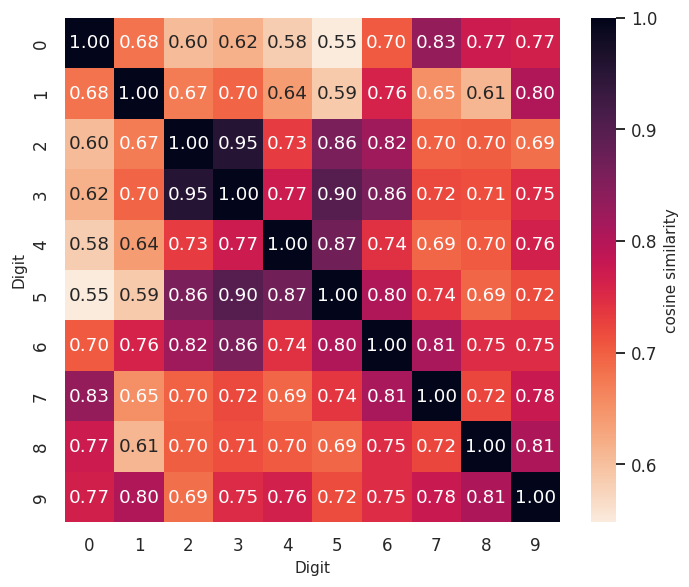

In [12]:
mean_imgs = np.stack([X_tr[y_tr == c].mean(axis=0).ravel()
                      for c in range(NUM_CLASSES)])
mean_imgs_n = mean_imgs / np.linalg.norm(mean_imgs, axis=1, keepdims=True)
sim = mean_imgs_n @ mean_imgs_n.T

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(sim, annot=True, fmt=".2f", cmap="rocket_r",
            xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES),
            cbar_kws={"label": "cosine similarity"})
plt.xlabel("Digit"); plt.ylabel("Digit")
plt.tight_layout(); plt.show()


## PCA and t-SNE

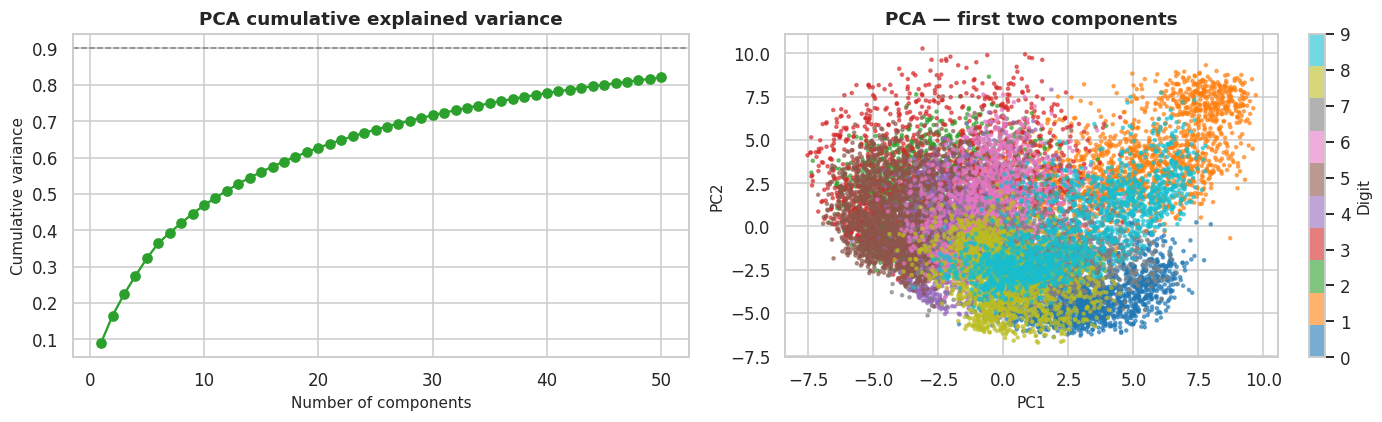

PCs needed to explain 90% variance: 51


In [13]:
X_flat = X_tr.reshape(len(X_tr), -1).astype(np.float32) / 255.0

pca_full = PCA(n_components=50, random_state=SEED).fit(X_flat)
expl = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(np.arange(1, 51), expl, marker="o", color=CLASS_PALETTE[2])
axes[0].axhline(0.9, ls="--", color="grey", lw=1)
axes[0].set_title("PCA cumulative explained variance")
axes[0].set_xlabel("Number of components")
axes[0].set_ylabel("Cumulative variance")

X_pca2 = pca_full.transform(X_flat)[:, :2]
sc = axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_tr, cmap="tab10",
                     s=4, alpha=0.6)
axes[1].set_title("PCA — first two components")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.colorbar(sc, ax=axes[1], label="Digit", ticks=range(NUM_CLASSES))
plt.tight_layout(); plt.show()

n90 = int(np.searchsorted(expl, 0.9) + 1)
print(f"PCs needed to explain 90% variance: {n90}")


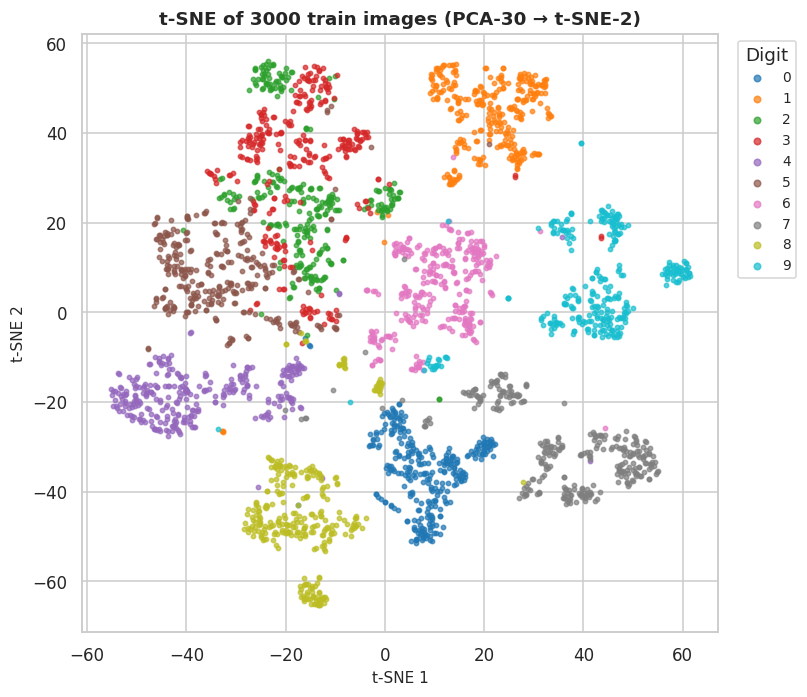

In [14]:
# t-SNE on a stratified sample of 3k for tractable runtime
N_TSNE = 3000
idx_per_class = [rng.choice(np.where(y_tr == c)[0],
                            size=N_TSNE // NUM_CLASSES, replace=False)
                 for c in range(NUM_CLASSES)]
idx = np.concatenate(idx_per_class)

X_pca30 = PCA(n_components=30, random_state=SEED).fit_transform(X_flat[idx])
emb = TSNE(n_components=2, perplexity=30, init="pca",
           learning_rate="auto", random_state=SEED).fit_transform(X_pca30)

plt.figure(figsize=(7.5, 6.5))
for c in range(NUM_CLASSES):
    m = y_tr[idx] == c
    plt.scatter(emb[m, 0], emb[m, 1], s=8, alpha=0.7,
                color=CLASS_PALETTE[c], label=str(c))
plt.legend(title="Digit", bbox_to_anchor=(1.02, 1), loc="upper left",
           markerscale=1.5, fontsize=9)
plt.title(f"t-SNE of {N_TSNE} train images (PCA-30 → t-SNE-2)")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.tight_layout(); plt.show()


##  Findings

10 classes are perfectly balanced. We can use plain cross-entropy with light label smoothing. No resampling.

cos similarity heatmap shows the confusables 4/9, 3/8 ...

Sharpness/edge density vary across classes, with low-quality outliers. We could do augmentations (affine, blur, erasing) so the model is robust to those.

Module 1 destroys grayscale information. Train on raw normalised grayscale.

t-SNE / PCA show partly-overlapping classes in raw pixel space. Some clusters show clearly in t-SNE

Theeres some near-duplicate ahashes inside train. We can use stratified kfold so it evaluates on samples the model has not seen.